In [2]:
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import requests
import seaborn as sns

In [3]:
original_df = pd.read_csv("demanddata_2025.csv")
original_df

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
1,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
3,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
4,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,2025-12-31,44,28633,30690,26868,3994,6606,0,22126,0,...,266,-212,912,-345,-145,96,1397,-82,1375,-514
17516,2025-12-31,45,27381,30212,25722,4027,6606,0,22126,0,...,27,-488,831,-432,-254,44,1397,-383,1372,-514
17517,2025-12-31,46,26563,29786,25049,4059,6606,0,22126,0,...,-19,-511,828,-452,-295,38,1368,-402,1370,-514
17518,2025-12-31,47,25481,30558,23955,4115,6606,0,22126,0,...,-1166,-658,622,-452,-383,-431,994,-415,1421,-514


In [4]:
original_df.describe()

,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.0,17520.000000,17520.000000,17520.000000,17520.000000,...,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,24.500228,26158.072603,28563.251256,23996.221975,1951.346233,6606.0,2130.222374,20813.171233,0.000228,172.601199,...,1179.809874,651.980479,50.336358,-254.829795,-192.334532,227.191610,1022.861130,672.369977,290.206792,-321.298345
std,13.854190,6172.933513,6107.866569,5650.814832,1279.663725,0.0,3281.983315,840.120108,0.021368,318.518752,...,687.094268,483.220995,723.071698,219.912302,237.632607,676.693354,636.782911,440.439194,854.485430,280.515292
min,1.000000,12803.000000,15297.000000,12040.000000,125.000000,6606.0,0.000000,19270.000000,0.000000,0.000000,...,-2071.000000,-1028.000000,-1093.000000,-453.000000,-532.000000,-1024.000000,-1453.000000,-1023.000000,-1453.000000,-539.000000
25%,12.750000,21432.750000,23897.750000,19638.000000,927.000000,6606.0,0.000000,20179.000000,0.000000,5.000000,...,978.750000,254.000000,-592.000000,-451.000000,-492.000000,-305.000000,916.000000,218.000000,-457.000000,-514.000000
50%,24.500000,24960.000000,27269.000000,22904.000000,1604.000000,6606.0,7.000000,20988.000000,0.000000,12.000000,...,1357.000000,984.000000,0.000000,-345.000000,-48.000000,348.000000,1395.000000,991.000000,461.000000,-506.000000
75%,36.250000,29825.250000,32193.250000,27386.250000,2756.000000,6606.0,3483.000000,21510.000000,0.000000,170.000000,...,1510.000000,992.000000,783.000000,-35.000000,0.000000,886.000000,1397.000000,996.000000,989.000000,-137.750000
max,50.000000,45924.000000,47760.000000,41835.000000,5922.000000,6606.0,14046.000000,22126.000000,2.000000,1739.000000,...,2024.000000,1058.000000,1116.000000,400.000000,504.000000,1063.000000,1491.000000,1063.000000,1428.000000,506.000000


In [5]:
df = original_df.copy()
df['grass_demand'] = df[['ND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']].sum(axis=1)
df['normalised_ND'] = (df['ND']-df["ND"].min()) / (df['ND'].max()-df['ND'].min())
df['normalised_grass_demand'] = (df['grass_demand']-df['grass_demand'].min()) / (df['grass_demand'].max()-df['grass_demand'].min())
df['ND/wind'] = df['ND'] / df['EMBEDDED_WIND_GENERATION']
df['NDxSolar'] = df['ND'] * df['EMBEDDED_SOLAR_GENERATION']
# print(df)

def period_to_timestamp(period):
    if period <= 48:
        total_minutes = (int(period) - 1) * 30
        hours = total_minutes // 60
        minutes = total_minutes % 60
        return f"{hours:02d}:{minutes:02d}"
    else:
        return np.nan

print("Converting periods to readable time strings...")
df['time_of_day'] = df['SETTLEMENT_PERIOD'].apply(period_to_timestamp)
df = df.dropna()

df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'])
df['month'] = df['SETTLEMENT_DATE'].dt.month
# print(df)
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

print("Mapping months to seasons...")
df['season'] = df['month'].apply(month_to_season)
# print(df)
# 3. Create a Wide Matrix structured by Season and Date
print("Pivoting data into a structured National Demand Matrix...")
# Rows = Date & Season, Columns = Time of Day (00:00 to 23:30)
demand_matrix = df[['SETTLEMENT_DATE', 'ND', 'normalised_ND', 'time_of_day', 
                'season', 'grass_demand', 'ND/wind', 'NDxSolar']]
                #.reset_index() #df.pivot(index=['season'], columns='time_of_day', values='normalised_ND').dropna()

demand_matrix['days_since_ith'] = (demand_matrix['SETTLEMENT_DATE'] - demand_matrix.loc[0, 'SETTLEMENT_DATE']).dt.days + 1

print("\nMatrix Shape:", demand_matrix.shape)
print("Preview of the structured matrix:")
demand_matrix

Converting periods to readable time strings...
Mapping months to seasons...
Pivoting data into a structured National Demand Matrix...

Matrix Shape: (17518, 9)
Preview of the structured matrix:


/var/folders/wn/7dpczcds351_x5wv54g1hhh80000gn/T/ipykernel_67250/1024579773.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demand_matrix['days_since_ith'] = (demand_matrix['SETTLEMENT_DATE'] - demand_matrix.loc[0, 'SETTLEMENT_DATE']).dt.days + 1


,SETTLEMENT_DATE,ND,normalised_ND,time_of_day,season,grass_demand,ND/wind,NDxSolar,days_since_ith
0,2025-01-01,21036,0.248573,00:00,Winter,26441,3.891952,0,1
1,2025-01-01,21222,0.254189,00:30,Winter,26580,3.960806,0,1
2,2025-01-01,21385,0.259111,01:00,Winter,26622,4.083445,0,1
3,2025-01-01,20473,0.231575,01:30,Winter,25588,4.002542,0,1
4,2025-01-01,19634,0.206244,02:00,Winter,24714,3.864961,0,1
...,...,...,...,...,...,...,...,...,...
17515,2025-12-31,28633,0.477945,21:30,Winter,32627,7.169004,0,365
17516,2025-12-31,27381,0.440144,22:00,Winter,31408,6.799354,0,365
17517,2025-12-31,26563,0.415446,22:30,Winter,30622,6.544223,0,365
17518,2025-12-31,25481,0.382778,23:00,Winter,29596,6.192224,0,365


In [6]:
demand_matrix.describe()

,SETTLEMENT_DATE,ND,normalised_ND,grass_demand,ND/wind,NDxSolar,days_since_ith
count,17518,17518.000000,17518.000000,17518.000000,17518.000000,1.751800e+04,17518.000000
mean,2025-07-02 00:15:27.229135872,26158.733360,0.403241,30240.230734,22.300328,5.051128e+07,183.010732
min,2025-01-01 00:00:00,12803.000000,0.000000,17416.000000,2.530737,0.000000e+00,1.000000
25%,2025-04-02 00:00:00,21434.000000,0.260590,25440.000000,9.443086,0.000000e+00,92.000000
50%,2025-07-02 00:00:00,24960.000000,0.367048,30033.000000,15.997068,1.716350e+05,183.000000
75%,2025-10-01 00:00:00,29825.750000,0.513956,34217.750000,27.453022,9.396382e+07,274.000000
max,2025-12-31 00:00:00,45924.000000,1.000000,48141.000000,328.688000,3.126016e+08,365.000000
std,NaN,6172.975105,0.186376,6305.226560,21.164794,7.284212e+07,105.370263


Aggregating month-long data into a single daily profile per substation...
Pivoting data for clustering...
Applying K-Means with 10 clusters...
Plotting Cluster Centroids...


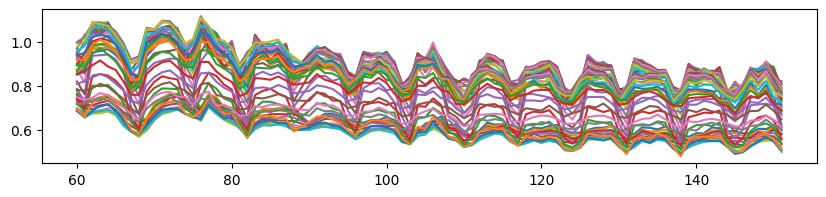

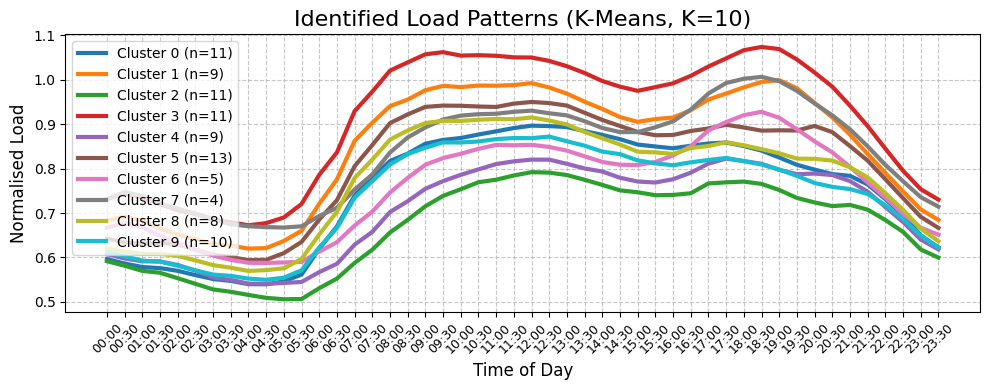

Aggregating month-long data into a single daily profile per substation...
Pivoting data for clustering...
Applying K-Means with 10 clusters...
Plotting Cluster Centroids...


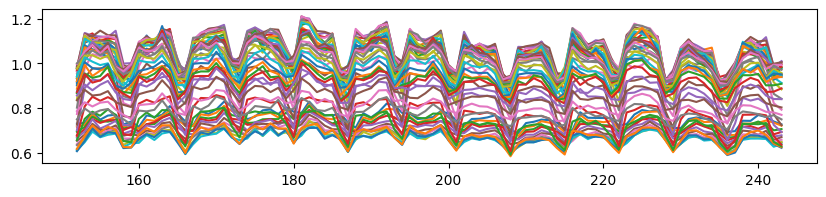

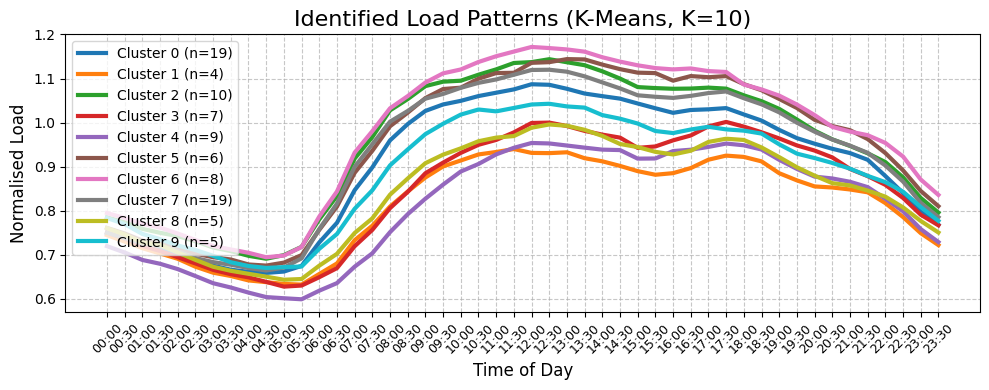

Aggregating month-long data into a single daily profile per substation...
Pivoting data for clustering...
Applying K-Means with 10 clusters...
Plotting Cluster Centroids...


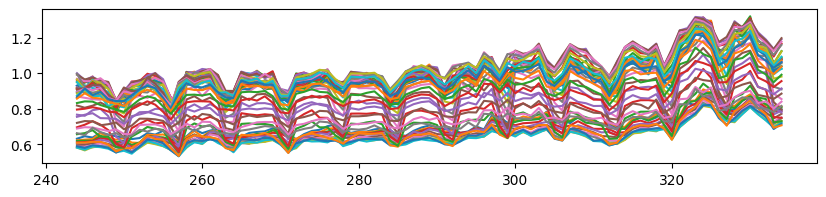

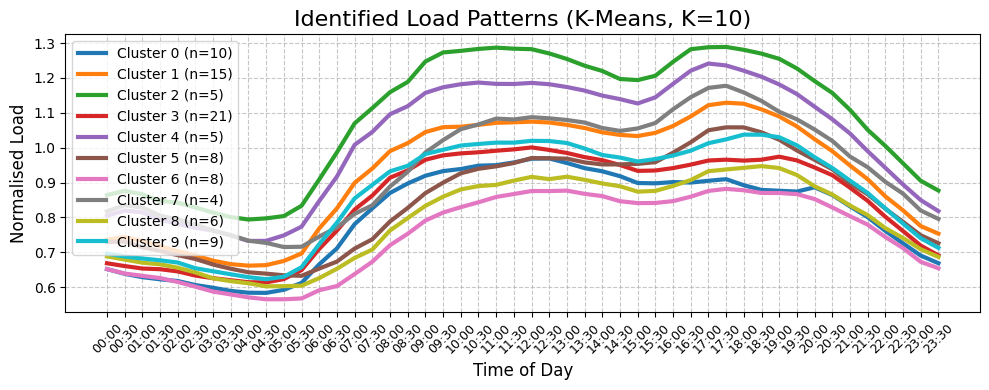

Aggregating month-long data into a single daily profile per substation...
Pivoting data for clustering...
Applying K-Means with 10 clusters...
Plotting Cluster Centroids...


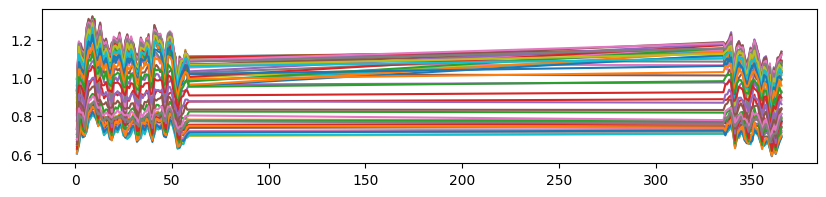

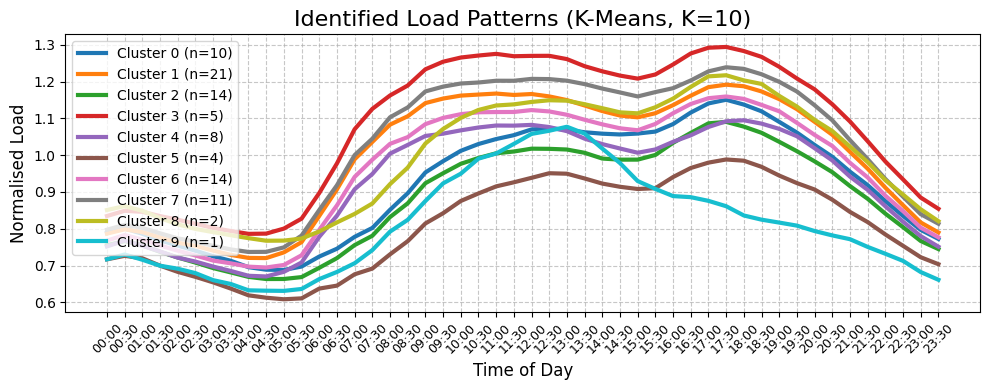

In [7]:
from sklearn.cluster import KMeans

def cluster_daily_patterns(df, n_clusters=3):

    for s in ['Spring', 'Summer', 'Autumn', 'Winter']:
        print("Aggregating month-long data into a single daily profile per substation...")
        # --- THE FIX: Average the 30 days into 1 typical day for EACH substation ---
        daily_profile = df.groupby(['days_since_ith', 'time_of_day', 'season'])['grass_demand'].mean().reset_index()
        # print(daily_profile)
        print("Pivoting data for clustering...")
        # Now it is safe to pivot because there is exactly one value per ID per time
        df_pivot = daily_profile[daily_profile['season']==s].pivot(index='days_since_ith', 
                                        columns='time_of_day', 
                                        values='grass_demand') # [daily_profile['season']=='Summer']
        df_pivot = df_pivot#.iloc[:, :-2]
        # Drop any substations that might have missing data for certain times
        df_pivot = df_pivot.dropna()
        df_pivot = df_pivot / (df_pivot.max(axis=1).iloc[0]) # normalised by daily peak
        plt.figure(figsize=(10, 2))
        plt.plot(df_pivot)
        print(f"Applying K-Means with {n_clusters} clusters...")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        
        # Fit the model and assign a cluster label to each substation
        df_pivot['Cluster'] = kmeans.fit_predict(df_pivot)

        # Visualize the distinct cluster profiles
        cluster_centers = df_pivot.groupby('Cluster').mean()

        print("Plotting Cluster Centroids...")
        plt.figure(figsize=(10, 4))
        
        # We transpose the centers just for easier plotting with pandas
        for cluster_id in cluster_centers.index:
            plt.plot(
                cluster_centers.columns, 
                cluster_centers.loc[cluster_id], 
                linewidth=3, 
                label=f'Cluster {cluster_id} (n={len(df_pivot[df_pivot["Cluster"] == cluster_id])})'
            )

        plt.title(f'Identified Load Patterns (K-Means, K={n_clusters})', fontsize=16)
        plt.xlabel('Time of Day', fontsize=12)
        plt.ylabel('Normalised Load', fontsize=12)
        plt.xticks(rotation=45, fontsize=9)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Return the dataframe with the cluster labels
    return df_pivot, df_pivot.reset_index()[['days_since_ith', 'Cluster']], cluster_centers

# Run it on your data
df_pivot, substation_clusters, cluster_centers = cluster_daily_patterns(demand_matrix, n_clusters=10)

Aggregating data into a single daily profile per substation...
Pivoting data for clustering...
Testing K values from 2 to 10...
Generating evaluation plots...


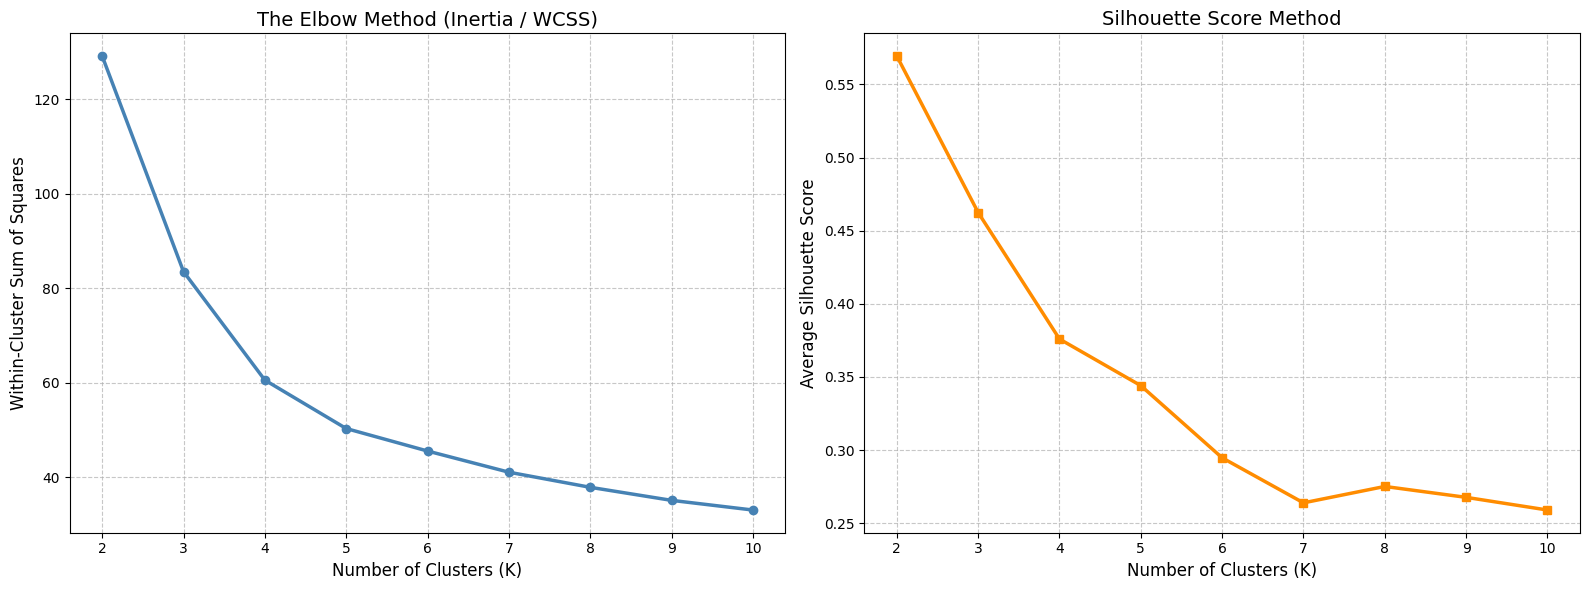

In [8]:
from sklearn.metrics import silhouette_score

def evaluate_optimal_k(df, max_k=10):
    print("Aggregating data into a single daily profile per substation...")
    # 1. Aggregate to handle the 30 days of data
    daily_profile = df.groupby(['days_since_ith', 'time_of_day'])['normalised_ND'].mean().reset_index()

    print("Pivoting data for clustering...")
    # 2. Pivot the data: Rows = Substations, Columns = Time of Day
    df_pivot = daily_profile.pivot(index='days_since_ith', columns='time_of_day', values='normalised_ND')
    df_pivot = df_pivot.dropna()

    # Lists to store the evaluation metrics
    wcss = []          # Within-Cluster Sum of Squares (Inertia)
    silhouette = []    # Silhouette Scores
    
    # We start at K=2 because Silhouette Score requires at least 2 clusters
    K_range = range(2, max_k + 1)

    print(f"Testing K values from 2 to {max_k}...")
    for k in K_range:
        # Initialize and fit K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(df_pivot)
        
        # Record the Inertia (WCSS)
        wcss.append(kmeans.inertia_)
        
        # Record the Silhouette Score
        sil_score = silhouette_score(df_pivot, cluster_labels)
        silhouette.append(sil_score)

    # 3. Plot the results
    print("Generating evaluation plots...")
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

    # --- Plot 1: The Elbow Curve (WCSS) ---
    axes[0].plot(K_range, wcss, marker='o', linewidth=2.5, color='steelblue')
    axes[0].set_title('The Elbow Method (Inertia / WCSS)', fontsize=14)
    axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[0].set_ylabel('Within-Cluster Sum of Squares', fontsize=12)
    axes[0].set_xticks(K_range)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: The Silhouette Score ---
    axes[1].plot(K_range, silhouette, marker='s', linewidth=2.5, color='darkorange')
    axes[1].set_title('Silhouette Score Method', fontsize=14)
    axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[1].set_ylabel('Average Silhouette Score', fontsize=12)
    axes[1].set_xticks(K_range)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

evaluate_optimal_k(demand_matrix, max_k=10)

In [9]:
demand_matrix

,SETTLEMENT_DATE,ND,normalised_ND,time_of_day,season,grass_demand,ND/wind,NDxSolar,days_since_ith
0,2025-01-01,21036,0.248573,00:00,Winter,26441,3.891952,0,1
1,2025-01-01,21222,0.254189,00:30,Winter,26580,3.960806,0,1
2,2025-01-01,21385,0.259111,01:00,Winter,26622,4.083445,0,1
3,2025-01-01,20473,0.231575,01:30,Winter,25588,4.002542,0,1
4,2025-01-01,19634,0.206244,02:00,Winter,24714,3.864961,0,1
...,...,...,...,...,...,...,...,...,...
17515,2025-12-31,28633,0.477945,21:30,Winter,32627,7.169004,0,365
17516,2025-12-31,27381,0.440144,22:00,Winter,31408,6.799354,0,365
17517,2025-12-31,26563,0.415446,22:30,Winter,30622,6.544223,0,365
17518,2025-12-31,25481,0.382778,23:00,Winter,29596,6.192224,0,365


1. Constructing the Matrix (Pivoting)...
2. Applying NMF to find 5 Latent Basis Curves...
This is weighted values:

                 Basis_1   Basis_2   Basis_3   Basis_4   Basis_5
days_since_ith                                                  
60              0.768092  0.230821  0.170826  0.082436  0.062962
61              0.737773  0.215381  0.123473  0.186293  0.094993
62              0.953978  0.066306  0.181739  0.115255  0.014560
63              0.931245  0.082980  0.199132  0.116021  0.035000
64              0.970526  0.078087  0.166009  0.095876  0.012633
...                  ...       ...       ...       ...       ...
147             0.805506  0.020340  0.039299  0.140675  0.064665
148             0.821070  0.045420  0.029617  0.078541  0.038446
149             0.839817  0.029097  0.039357  0.100814  0.056132
150             0.832261  0.061640  0.028160  0.037508  0.002532
151             0.697538  0.113831  0.017517  0.081228  0.068413

[91 rows x 5 columns]
Plotting the und

/opt/miniconda3/envs/conv-seq/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


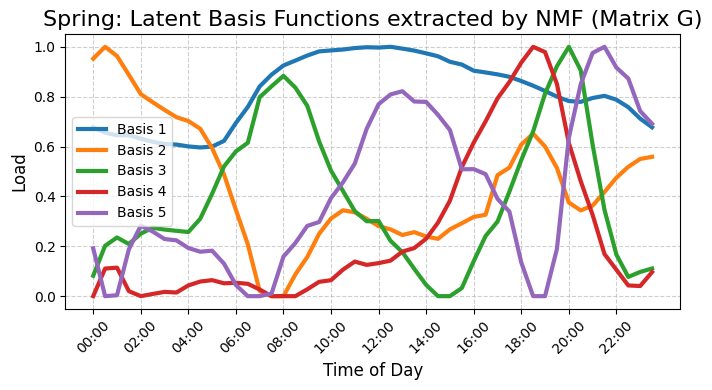

1. Constructing the Matrix (Pivoting)...
2. Applying NMF to find 5 Latent Basis Curves...
This is weighted values:

                 Basis_1   Basis_2   Basis_3   Basis_4   Basis_5
days_since_ith                                                  
152             0.843215  0.179830  0.000000  0.045630  0.041877
153             1.015105  0.034116  0.040879  0.073593  0.074623
154             1.062736  0.023900  0.078911  0.011138  0.007713
155             1.041109  0.011704  0.070687  0.027229  0.045789
156             1.052854  0.019387  0.071532  0.000000  0.058427
...                  ...       ...       ...       ...       ...
239             0.978767  0.062072  0.052388  0.078889  0.062192
240             0.974657  0.061104  0.056645  0.054586  0.078646
241             0.909674  0.075537  0.090239  0.111626  0.052204
242             0.858393  0.148722  0.025489  0.041259  0.076884
243             0.831869  0.181655  0.008147  0.091054  0.067258

[92 rows x 5 columns]
Plotting the und

/opt/miniconda3/envs/conv-seq/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


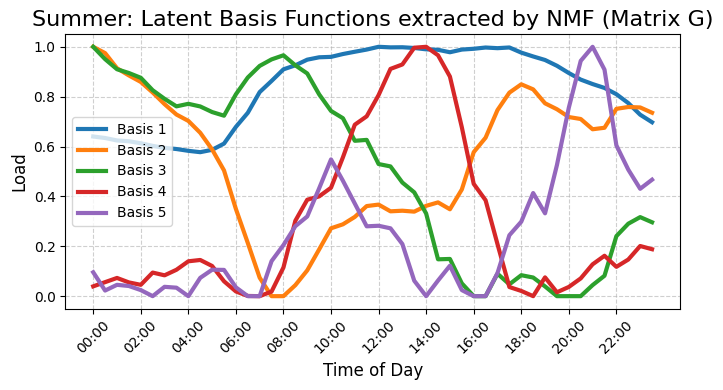

1. Constructing the Matrix (Pivoting)...
2. Applying NMF to find 5 Latent Basis Curves...
This is weighted values:

                 Basis_1   Basis_2   Basis_3   Basis_4   Basis_5
days_since_ith                                                  
244             0.903556  0.043636  0.031318  0.000000  0.102973
245             0.902142  0.056459  0.028974  0.030821  0.049967
246             0.897711  0.049626  0.039903  0.010233  0.115865
247             0.887818  0.040963  0.060766  0.044349  0.084948
248             0.899286  0.006094  0.062122  0.008847  0.068082
...                  ...       ...       ...       ...       ...
330             1.221588  0.013224  0.078784  0.156202  0.089209
331             1.079971  0.033605  0.137823  0.174610  0.095276
332             1.100695  0.004217  0.098532  0.145872  0.089293
333             0.887916  0.180445  0.158720  0.106542  0.102560
334             0.878090  0.241135  0.162128  0.115040  0.115999

[91 rows x 5 columns]
Plotting the und

/opt/miniconda3/envs/conv-seq/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


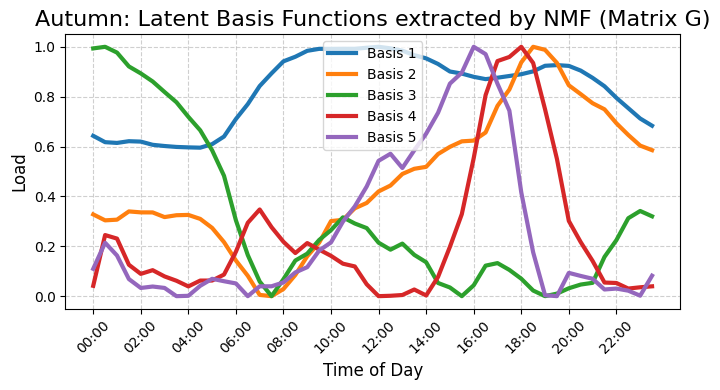

1. Constructing the Matrix (Pivoting)...
2. Applying NMF to find 5 Latent Basis Curves...
This is weighted values:

                 Basis_1   Basis_2   Basis_3   Basis_4   Basis_5
days_since_ith                                                  
1               0.931207  0.000000  0.138621  0.113958  0.049433
2               1.177220  0.124214  0.000000  0.056016  0.000000
3               1.085176  0.246209  0.130134  0.105175  0.055181
4               1.091480  0.080021  0.122911  0.075865  0.035183
5               1.053552  0.041165  0.120188  0.151869  0.063594
...                  ...       ...       ...       ...       ...
361             0.994339  0.089455  0.108825  0.095288  0.033730
362             0.974563  0.021121  0.115521  0.124239  0.035112
363             1.050838  0.080665  0.061806  0.081854  0.048156
364             1.070275  0.105849  0.098760  0.049012  0.028219
365             1.040431  0.153169  0.142914  0.112838  0.036729

[90 rows x 5 columns]
Plotting the und

/opt/miniconda3/envs/conv-seq/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


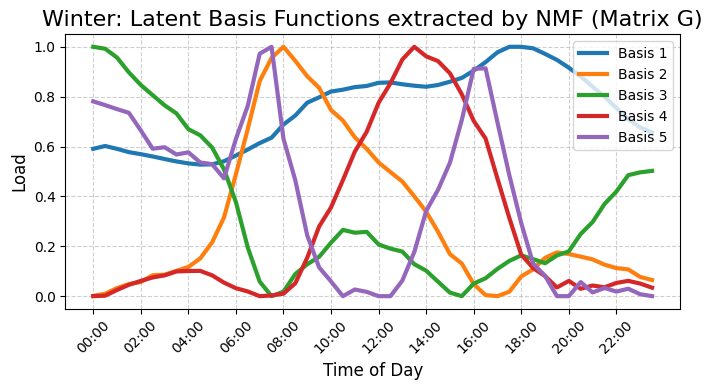

In [16]:
from sklearn.decomposition import NMF

def apply_nmf_to_profiles(df, n_components=4):
    bigW = []
    bigH = []
    for s in ['Spring', 'Summer', 'Autumn', 'Winter']: 
        print("1. Constructing the Matrix (Pivoting)...")
        # Grouping by time_of_day to get the average daily profile per substation
        daily_profile = df.groupby(['days_since_ith', 'time_of_day', 'season'])['grass_demand'].mean().reset_index()
    
        # This is our Matrix V
        V = daily_profile[daily_profile['season']==s].pivot(index='days_since_ith', 
                                        columns='time_of_day', 
                                        values='grass_demand')
        V = V.dropna()
        V = V / (V.max(axis=1).iloc[0]) #df.groupby(['season', 'time_of_day'])['grass_demand'].mean().reset_index()
        # print(V)
        print(f"2. Applying NMF to find {n_components} Latent Basis Curves...")
        # Initialize NMF. We use 'n_components' to define how many basic shapes we want to find.
        nmf_model = NMF(n_components=n_components, init='nndsvd', random_state=42, max_iter=500)
        
        # Fit the model to get Matrix W (Weights) and Matrix H (Basis Curves)
        W = nmf_model.fit_transform(V) 
        H = nmf_model.components_

        scale_factors = H.max(axis=1, keepdims=True)
        H_normalised = H / scale_factors
        W_compensated = W * scale_factors.T
        
        # 3. Format the outputs into Pandas DataFrames for easy reading
        # Matrix H: The pure archetypal shapes
        basis_curves = pd.DataFrame(H_normalised, columns=V.columns)
        basis_curves.index = [f'Basis_{i+1}' for i in range(n_components)]
        
        # Matrix W: The mix/weights for each substation
        daily_weights = pd.DataFrame(W_compensated, index=V.index, columns=basis_curves.index)
        print("This is weighted values:\n")
        print(daily_weights)

        bigH.append(basis_curves)
        bigW.append(daily_weights)

        # 4. Visualize the Basis Curves (Matrix H)
        print("Plotting the underlying Basis Curves...")
        plt.figure(figsize=(7, 4))
        for i in range(n_components):
            plt.plot(basis_curves.columns, basis_curves.iloc[i], linewidth=3, label=f'Basis {i+1}')
            
        plt.title(f'{s}: Latent Basis Functions extracted by NMF (Matrix G)', fontsize=16)
        plt.xlabel('Time of Day', fontsize=12)
        plt.ylabel('Load', fontsize=12)
        plt.xticks(range(0, 48, 4), rotation=45)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    return bigH, bigW #basis_curves, daily_weights

H_matrix, W_matrix = apply_nmf_to_profiles(demand_matrix, n_components=5)

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Optional but highly recommended

print("1. Concatenating the list of pivot tables...")
# axis=0 stacks them vertically. 
# ignore_index=True resets the row index from 0 to 19. 
# (If your original index contains important IDs or dates, remove ignore_index=True)
# combined_H_matrix = pd.concat(H_matrix, axis=0, ignore_index=True)

print(f"Combined matrix shape: {combined_H_matrix.shape}") # Should output (20, 48)

combined_H_matrix = combined_H_matrix#.div(combined_H_matrix.max(axis=1), axis=0)

print("2. Running K-Means clustering...")
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(combined_H_matrix)

combined_H_matrix['Cluster'] = cluster_labels

print("Clustering complete! Here is a preview:")
print(combined_H_matrix[['Cluster']])

1. Concatenating the list of pivot tables...
Combined matrix shape: (20, 49)
2. Running K-Means clustering...
Clustering complete! Here is a preview:
time_of_day  Cluster
0                  2
1                  3
2                  1
3                  5
4                  8
5                  2
6                  4
7                  0
8                  9
9                  8
10                 2
11                 6
12                 3
13                 5
14                 7
15                 2
16                 1
17                 3
18                 9
19                 5


Extracting cluster centroids and generating profile visualization...


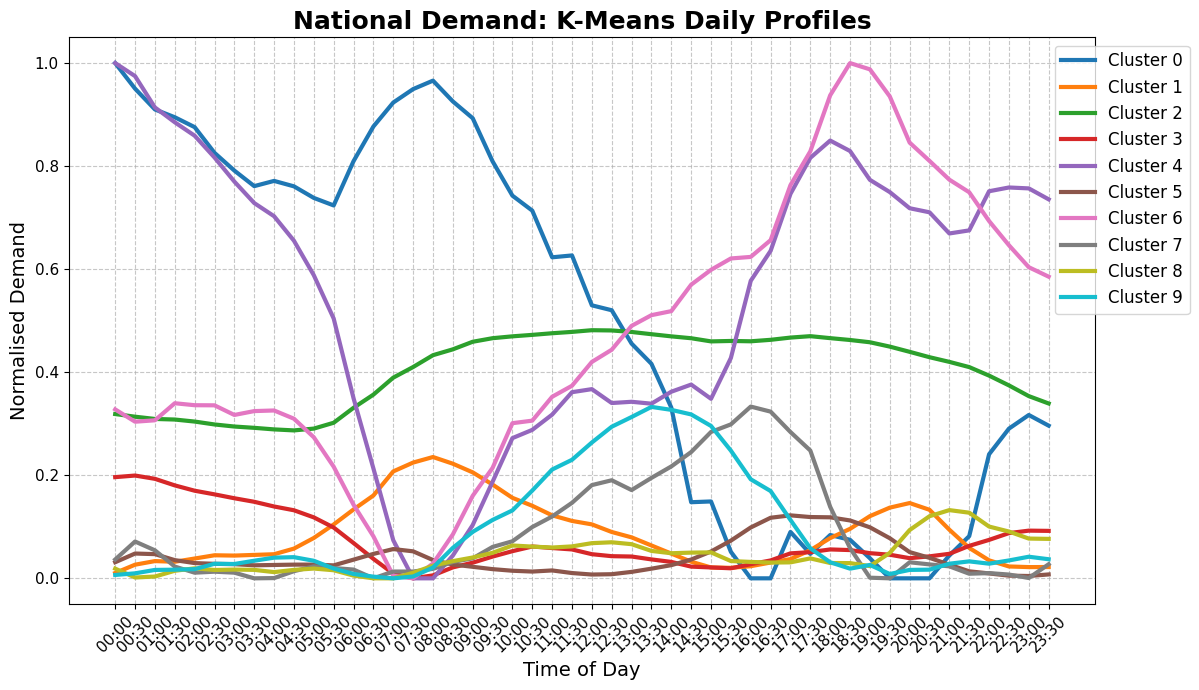

In [52]:
print("Extracting cluster centroids and generating profile visualization...")

cluster_centers = kmeans.cluster_centers_

# 2. Generate readable time labels for the X-axis (00:00 to 23:30)
time_labels = []
for i in range(48):
    hours = (i * 30) // 60
    minutes = (i * 30) % 60
    time_labels.append(f"{hours:02d}:{minutes:02d}")

# 3. Create the visualization
plt.figure(figsize=(12, 7))

# Loop through each cluster and plot its centroid curve
for i in range(len(cluster_centers)):
    plt.plot(
        time_labels, 
        cluster_centers[i][:48], 
        linewidth=3, 
        label=f'Cluster {i}'
    )

# 4. Format the chart for professional presentation
plt.title('National Demand: K-Means Daily Profiles', fontsize=18, fontweight='bold')
plt.xlabel('Time of Day', fontsize=14)
plt.ylabel('Normalised Demand', fontsize=14)

plt.xticks(np.arange(0, 48, step=1), rotation=45, fontsize=11) 
plt.yticks(fontsize=11)

plt.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1.1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

1. Constructing the Matrix (Pivoting)...
2. Applying NMF to find 10 Latent Basis Curves...


/opt/miniconda3/envs/conv-seq/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


This is weighted values:

                 Basis_1   Basis_2   Basis_3   Basis_4   Basis_5   Basis_6  \
days_since_ith                                                               
1               0.734626  0.179244  0.151003  0.178657  0.079740  0.000000   
2               0.994423  0.041445  0.210107  0.086419  0.063522  0.080175   
3               1.072447  0.045766  0.090117  0.054053  0.029140  0.100213   
4               0.950555  0.118717  0.151457  0.092253  0.057104  0.010166   
5               0.905100  0.106918  0.175921  0.163556  0.056336  0.016196   
...                  ...       ...       ...       ...       ...       ...   
361             0.866754  0.093400  0.136648  0.101899  0.061772  0.051348   
362             0.789373  0.148278  0.155215  0.161278  0.066918  0.037997   
363             0.893961  0.070789  0.178372  0.106233  0.061455  0.039046   
364             0.954253  0.110744  0.119505  0.055108  0.053847  0.010032   
365             1.019749  0.107306  0.

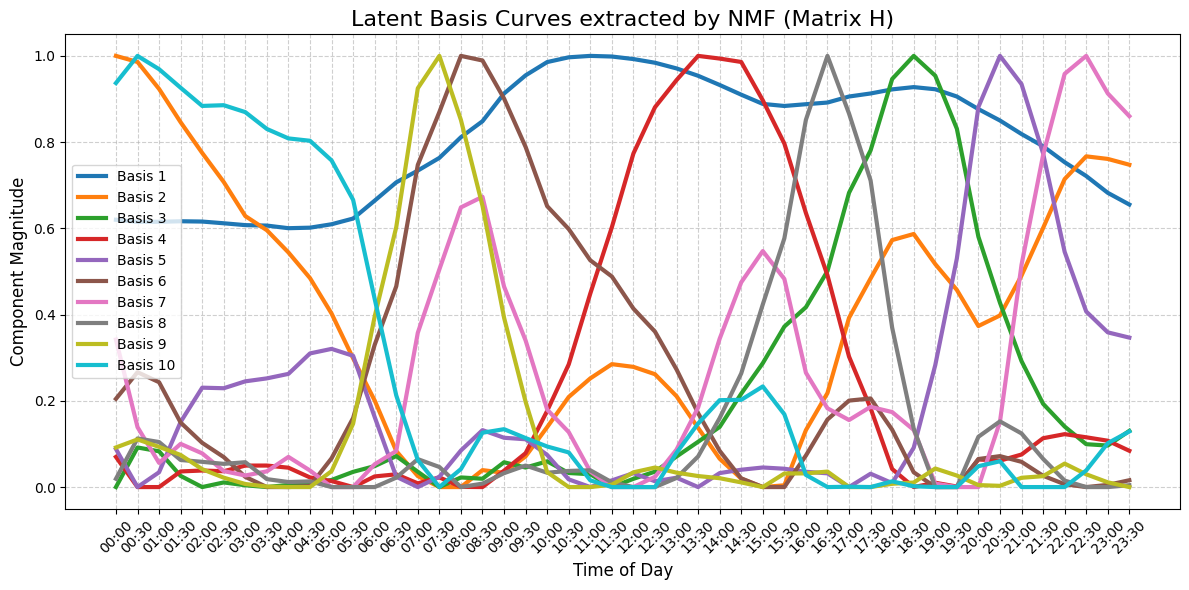

In [53]:
from sklearn.decomposition import NMF

def apply_nmf_to_profiles(df, n_components=4):
    print("1. Constructing the Matrix (Pivoting)...")
    # Grouping by time_of_day to get the average daily profile per substation
    daily_profile = df.groupby(['days_since_ith', 'time_of_day', 'season'])['grass_demand'].mean().reset_index()

    # This is our Matrix V
    V = daily_profile.pivot(index='days_since_ith', 
                                    columns='time_of_day', 
                                    values='grass_demand')
    V = V.dropna()
    V = V / (V.max(axis=1).iloc[0]) #df.groupby(['season', 'time_of_day'])['grass_demand'].mean().reset_index()
    # print(V)
    print(f"2. Applying NMF to find {n_components} Latent Basis Curves...")
    # Initialize NMF. We use 'n_components' to define how many basic shapes we want to find.
    nmf_model = NMF(n_components=n_components, init='nndsvd', random_state=42, max_iter=500)
    
    # Fit the model to get Matrix W (Weights) and Matrix H (Basis Curves)
    W = nmf_model.fit_transform(V) 
    H = nmf_model.components_

    scale_factors = H.max(axis=1, keepdims=True)
    H_normalised = H / scale_factors
    W_compensated = W * scale_factors.T
    
    # 3. Format the outputs into Pandas DataFrames for easy reading
    # Matrix H: The pure archetypal shapes
    basis_curves = pd.DataFrame(H_normalised, columns=V.columns)
    basis_curves.index = [f'Basis_{i+1}' for i in range(n_components)]
    
    # Matrix W: The mix/weights for each substation
    daily_weights = pd.DataFrame(W_compensated, index=V.index, columns=basis_curves.index)
    print("This is weighted values:\n")
    print(daily_weights)

    # 4. Visualize the Basis Curves (Matrix H)
    print("Plotting the underlying Basis Curves...")
    plt.figure(figsize=(12, 6))
    for i in range(n_components):
        plt.plot(basis_curves.columns, basis_curves.iloc[i], linewidth=3, label=f'Basis {i+1}')
        
    plt.title('Latent Basis Curves extracted by NMF (Matrix H)', fontsize=16)
    plt.xlabel('Time of Day', fontsize=12)
    plt.ylabel('Component Magnitude', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return basis_curves, daily_weights

H_matrix, W_matrix = apply_nmf_to_profiles(demand_matrix, n_components=10)